# **Advanced Machine Learning Methods**
## **Maestría en Inteligencia Artificial Aplicada**
### **Dr. José Antonio Cantoral Ceballos**
### **Tecnológico de Monterrey**
## **Activity 3b: Text Classification using RNNs and AG_NEWS dataset in PyTorch**

---

### Team 7

- Rodrigo Robledo Castillo - A01797582
- Pedro David Juarez Leyva - A01797041
- Emilio Contreras Téllez - A01111353
- Omar Aguilar Macedo - A0179707

# Table of Contents

1. [Activity 3b: Text Classification using RNNs and AG_NEWS dataset in PyTorch](#activity_3b)
1. [Introduction](#introduction)
1. [Load dataset](#load)
1. [Build RNN Model](#build_rnn)
1. [Accuracy](#accuracy)
1. [Train Loop](#train_loop)
1. [Train Models](#train)
    1. [Baseline RNN](#baseline)
    1. [GRU](#gru)
    1. [LSTM](#lst)
1. [Sampler](#sampler)
1. [Confusion Matrix](#confusion_matrix)
    1. [Baseline RNN](#cm_baseline)
    1. [GRU](#cm_gru)
    1. [LSTM](#cm_lstm)
1. [Model Architecture and Training](#arch)
1. [Results](#results)
1. [Conclusions](#conclusions)

## TC 5033
### Text Classifier with RNNs

<br>

#### Activity 3b: Text Classification using RNNs and AG_NEWS dataset in PyTorch <a name="activity_3b" />
<br>

- Objective:
    - Understand the basics of Recurrent Neural Networks (RNNs) and their application in text classification.
    - Learn how to handle a real-world text dataset, AG_NEWS, in PyTorch.
    - Gain hands-on experience in defining, training, and evaluating a text classification model in PyTorch.
    
<br>

- Instructions:
    - Data Preparation: Starter code will be provided that loads the AG_NEWS dataset and prepares it for training. Do not modify this part. However, you should be sure to understand it, and comment it, the use of markdown cells is suggested.

    - Model Setup: A skeleton code for the RNN model class will be provided. Complete this class and use it to instantiate your model.

    - Implementing Accuracy Function: Write a function that takes model predictions and ground truth labels as input and returns the model's accuracy.

    - Training Function: Implement a function that performs training on the given model using the AG_NEWS dataset. Your model should achieve an accuracy of at least 80% to get full marks for this part.

    - Text Sampling: Write a function that takes a sample text as input and classifies it using your trained model.

    - Confusion Matrix: Implement a function to display the confusion matrix for your model on the test data.

    - Submission: Submit your completed Jupyter Notebook. Make sure to include a markdown cell at the beginning of the notebook that lists the names of all team members. Teams should consist of 3 to 4 members.
    
<br>

- Evaluation Criteria:

    - Correct setup of all the required libraries and modules (10%)
    - Code Quality (30%): Your code should be well-organized, clearly commented, and easy to follow. Use also markdown cells for clarity. Comments should be given for all the provided code, this will help you understand its functionality.
    
   - Functionality (60%):
        - All the functions should execute without errors and provide the expected outputs.
        - RNN model class (20%)
        - Accuracy fucntion (10%)
        - Training function (10%)
        - Sampling function (10%)
        - Confucion matrix (10%)

        - The model should achieve at least an 80% accuracy on the AG_NEWS test set for full marks in this criterion.


Dataset

https://pytorch.org/text/stable/datasets.html#text-classification

https://paperswithcode.com/dataset/ag-news


# Introduction <a name="introduction" />

Text classification is a fundamental task in Natural Language Processing (NLP) that involves assigning predefined categories to textual data. This task is widely used in applications such as news categorization, sentiment analysis, spam detection, and document organization. With the increasing availability of large text corpora, machine learning and deep learning methods have become essential tools for automatically extracting meaningful patterns from textual information.

Recurrent Neural Networks (RNNs) are a class of neural networks designed to process sequential data by maintaining an internal hidden state that captures contextual information across time steps. This property makes them particularly suitable for modeling natural language, where the meaning of a word often depends on its surrounding context. However, traditional RNNs can struggle with long-range dependencies due to issues such as vanishing gradients. To address these limitations, more advanced recurrent architectures such as Gated Recurrent Units (GRUs) and Long Short-Term Memory (LSTM) networks have been proposed. These architectures incorporate gating mechanisms that allow the network to better preserve and control the flow of information through the sequence.

In this activity, recurrent neural network architectures are applied to the task of news topic classification using the **AG_NEWS** dataset. The dataset contains news articles categorized into four classes: **World, Sports, Business, and Sci/Tech**. The implemented model pipeline includes text tokenization, vocabulary construction, sequence padding, and the use of an embedding layer to transform tokens into dense vector representations. Three different recurrent architectures (RNN, GRU, and LSTM) are trained and compared in order to evaluate their performance on the classification task. Model performance is measured using classification accuracy and analyzed further through confusion matrices to better understand the behavior of each architecture.

#### Install libraries

You may need to install the following libraries, also you may need to adjust library versions to ensure compatibility, depending on the versions you have previously installed. After installing them, please Restart the Session (Runtime -> Restart Session), or Kernel - Restart Kerne

In [1]:
!pip install torch==2.2.0 torchvision==0.17.0 torchaudio==2.2.0 torchtext==0.17 #0.16.2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 755.5/755.5 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 82.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 90.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 121.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 104.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 83.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 73.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196

In [9]:
!pip install scipy==1.9.3
!pip install scikit-plot
#you may receive a message of restarting session, this is OK

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.4/33.4 MB 25.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 60.2 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: scipy
    Found existing installation: scipy 1.15.3
    Uninstalling scipy-1.15.3:
      Successfully uninstalled scipy-1.15.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
albumentations 2.0.8 requires scipy>=1.10.0, but you have scipy 1.9.3 which is incompatible.
blosc2 3.5.1 requires numpy>=1.26, but you have numpy 1.25.2 which is incompatible.
cvxpy 1.6.6 requires scipy>=1.11.0, but you have scipy 1.9.3 which is incompatible.
imbalanced-learn 0.13.0 req

In [4]:
!pip install portalocker
#please restar session after this intallation. After restarting go straight to importing the libraries

In [6]:
!pip cache purge

Files removed: 108


## Import libraries

In [1]:
# The following libraries are required for running the given code
# Please feel free to add any libraries you consider adecuate to complete the assingment.
import numpy as np
#PyTorch libraries
import torch
from torchtext.datasets import AG_NEWS
# Dataloader library
from torch.utils.data import DataLoader
from torch.utils.data.dataset import random_split
# Libraries to prepare the data
from torchtext.data.utils import get_tokenizer
from torchtext.vocab import build_vocab_from_iterator
from torchtext.data.functional import to_map_style_dataset
# neural layers
from torch import nn
from torch.nn import functional as F

# These libraries are suggested to plot confusion matrix
# you may use others
# import scikitplot as skplt
# import gc

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [2]:
# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


### Get the train and the test datasets and dataloaders <a name="load" />

Classes:

* 1 - World

* 2 - Sports

* 3 - Business

* 4 - Sci/Tech

We will convert them to:

* 0 - World

* 1 - Sports

* 2 - Business

* 3 - Sci/Tech

In [3]:
# Load the AG_NEWS dataset from torchtext
# The dataset initially returns an iterable dataset
train_dataset, test_dataset = AG_NEWS()

# Convert iterable datasets into map-style datasets so they can be indexed
# This allows us to use utilities such as random_split and DataLoader shuffling
train_dataset, test_dataset = to_map_style_dataset(train_dataset), to_map_style_dataset(test_dataset)

In [4]:
# Initialize the tokenizer
# 'basic_english' lowercases text and splits on punctuation/whitespace
tokenizer = get_tokenizer('basic_english')

# Generator function used to build the vocabulary
# It iterates through the dataset and yields tokenized text
# This is typically used by torchtext to construct the vocab
def yield_tokens(data):
    for _, text in data:
        yield tokenizer(text)

In [5]:
# Build the vocabulary
vocab = build_vocab_from_iterator(yield_tokens(train_dataset), specials=["<unk>"])
#set unknown token at position 0
vocab.set_default_index(vocab["<unk>"])

In [6]:
# test tokens, TC5033 is maped to 0 as is an unknown token (<unk>)
tokens = tokenizer('Welcome to TC5033')
print(tokens, vocab(tokens))

['welcome', 'to', 'tc5033'] [3314, 4, 0]


In [7]:
# Split the original training dataset into training and validation sets
# 90% of the data will be used for training and 10% for validation
NUM_TRAIN = int(len(train_dataset) * 0.9)
NUM_VAL = len(train_dataset) - NUM_TRAIN

In [8]:
train_dataset, val_dataset = random_split(train_dataset, [NUM_TRAIN, NUM_VAL])

In [9]:
# Print dataset sizes to verify the split
print(len(train_dataset), len(val_dataset), len(test_dataset))

108000 12000 7600


In [10]:
# Example: retrieve the first 10 tokens from the vocabulary
# This helps verify that the vocabulary was constructed correctly
vocab.lookup_tokens(range(10))

['<unk>', '.', 'the', ',', 'to', 'a', 'of', 'in', 'and', 's']

In [11]:
# Function used by DataLoader to assemble batches
# This function converts raw text into padded sequences of token indices
def collate_batch(batch):
    # Separate labels and text from the batch
    y, x = list(zip(*batch))

    # Convert each text sample into a sequence of token indices
    # vocab(tokenizer(text)) maps tokens to their corresponding vocabulary ids
    x = [vocab(tokenizer(text)) for text in x]

    # Pad or truncate each sequence to a fixed length (max_tokens)
    # Padding uses index 0
    x = [t + ([0]*(max_tokens - len(t))) if len(t) < max_tokens else t[:max_tokens] for t in x]

    # Convert labels to tensor and shift them from range [1..4] to [0..3]
    # CrossEntropyLoss expects class indices starting from 0
    return torch.tensor(x, dtype=torch.int32), torch.tensor(y, dtype=torch.int32) - 1

In [12]:
# Class labels for the AG_NEWS dataset
labels = ["World", "Sports", "Business", "Sci/Tech"]

# Maximum sequence length used for padding/truncation
max_tokens = 50

# Number of samples processed in each training batch
BATCH_SIZE = 256


In [13]:
# DataLoader for the training set
# shuffle=True ensures batches are randomized each epoch
train_loader = DataLoader(train_dataset,
                          batch_size=BATCH_SIZE,
                          collate_fn=collate_batch,
                          shuffle = True)

# DataLoader for the validation set
val_loader = DataLoader(val_dataset,
                        batch_size=BATCH_SIZE,
                        collate_fn=collate_batch,
                        shuffle = True)

# DataLoader for the test set
test_loader = DataLoader(test_dataset,
                         batch_size=BATCH_SIZE,
                         collate_fn=collate_batch,
                         shuffle = True)

### Let us build our RNN model <a name="build_rnn" />

In [14]:
# Model hyperparameters
# EMBEDDING_SIZE: dimensionality of the word embeddings
# NEURONS: number of hidden units in the recurrent layer
# LAYERS: number of stacked recurrent layers
# NUM_CLASSES: number of output classes for AG_NEWS
EMBEDDING_SIZE = 300
NEURONS = 256
LAYERS = 2
NUM_CLASSES = 4

In [15]:
class RNN_Model_1(nn.Module):
  def __init__(self, embed_size, hidden, layers, num_classes,
                 rnn_type = "rnn"):
    super().__init__()

    # Embedding layer maps token indices to dense vector representations
    # Input shape: (batch_size, sequence_length)
    # Output shape: (batch_size, sequence_length, embed_size)
    self.embedding_layer = nn.Embedding(num_embeddings=len(vocab),
                                        embedding_dim=embed_size)

    # Select the recurrent architecture dynamically
    # Options: simple RNN, GRU, or LSTM
    if rnn_type == "rnn":
        self.rnn = nn.RNN(embed_size, hidden, num_layers=layers, batch_first=True)
    elif rnn_type == "gru":
        self.rnn = nn.GRU(embed_size, hidden, num_layers=layers, batch_first=True)
    elif rnn_type == "lstm":
        self.rnn = nn.LSTM(embed_size, hidden, num_layers=layers, batch_first=True)
    else:
        raise ValueError("rnn_type must be one of: rnn, gru, lstm")

    # Fully connected classification layer
    # Maps the final hidden state to the output class logits
    self.fc = nn.Linear(hidden, num_classes)

  def forward(self, x):
    # Convert token indices to embeddings
    embedded = self.embedding_layer(x)

    # Pass embeddings through the recurrent layer
    # hidden contains the final hidden state(s)
    _, hidden = self.rnn(embedded)

    # LSTM returns a tuple (hidden_state, cell_state)
    # while RNN and GRU return only the hidden_state
    if isinstance(hidden, tuple):
      h_n, c_n = hidden
      out = h_n[-1] # last layer hidden state (B, H)
    else:
      out = hidden[-1] # last layer hidden state (B, H)

    # Final classification layer
    return self.fc(out)


## Accuracy <a name="accuracy" />

In [16]:
# Compute classification accuracy on a dataset
def accuracy(model, dataloader, device = device):
  model = model.to(device)
  model.eval()  # Switch model to evaluation mode

  correct = 0
  total = 0

  # Disable gradient computation for efficiency during evaluation
  with torch.no_grad():
    for text, labels in dataloader:
      text = text.to(device, dtype=torch.long)
      labels = labels.to(device, dtype=torch.long)

      scores = model(text)

      # Predicted class = index of highest logit
      predicted = scores.argmax(dim=1)

      total += labels.size(0)
      correct += (predicted == labels).sum().item()

  return correct / total

## Train Loop <a name="train_loop" />

In [17]:
# Training loop
def train(model, optimizer, dataloader, loss_fn = nn.CrossEntropyLoss(),
          epochs=100, device = device):
  model = model.to(device)

  for epoch in range(epochs):
    # Switch model to training mode each epoch
    model.train()

    for text, labels in dataloader:
      text = text.to(device, dtype=torch.long)
      labels = labels.to(device, dtype=torch.long)

      # Forward pass
      predictions = model(text)

      # Compute loss between predictions and ground truth labels
      loss = loss_fn(predictions, labels)

      # Reset gradients before backpropagation
      optimizer.zero_grad()

      # Compute gradients
      loss.backward()

      # Update model parameters
      optimizer.step()

    # Evaluate model on validation set
    acc = accuracy(model, val_loader)

    print(f'Epoch: {epoch}, cost: {loss.item()}, accuracy: {acc},')


# Train Models <a name="train" />

## Basline RNN model <a name="baseline" />

In [18]:
epochs = 20
lr     = 1e-3;
# instantiate baseline RNN model
rnn_model = RNN_Model_1(EMBEDDING_SIZE, NEURONS, LAYERS, NUM_CLASSES)
optimizer = torch.optim.Adam(rnn_model.parameters(), lr=lr)

In [19]:
# Train the model
train(rnn_model, optimizer, train_loader, epochs=epochs)

Epoch: 0, cost: 1.3871440887451172, accuracy: 0.27708333333333335,
Epoch: 1, cost: 1.3874262571334839, accuracy: 0.30325,
Epoch: 2, cost: 1.125895380973816, accuracy: 0.5455833333333333,
Epoch: 3, cost: 1.2518384456634521, accuracy: 0.2896666666666667,
Epoch: 4, cost: 0.9528941512107849, accuracy: 0.61975,
Epoch: 5, cost: 0.744351327419281, accuracy: 0.6540833333333333,
Epoch: 6, cost: 0.9070890545845032, accuracy: 0.602,
Epoch: 7, cost: 0.8473493456840515, accuracy: 0.6363333333333333,
Epoch: 8, cost: 0.9045558571815491, accuracy: 0.6793333333333333,
Epoch: 9, cost: 0.9423967003822327, accuracy: 0.5831666666666667,
Epoch: 10, cost: 0.8003901243209839, accuracy: 0.62075,
Epoch: 11, cost: 0.8121770024299622, accuracy: 0.6493333333333333,
Epoch: 12, cost: 0.8951354622840881, accuracy: 0.64825,
Epoch: 13, cost: 0.7843931913375854, accuracy: 0.6615833333333333,
Epoch: 14, cost: 0.7452227473258972, accuracy: 0.6663333333333333,
Epoch: 15, cost: 0.8096691966056824, accuracy: 0.665,
Epoch: 16

In [20]:
# Evaluate on test set
print(f'{accuracy(rnn_model, test_loader):.4f}')

0.6174


## GRU model <a name="gru" />

In [21]:
epochs = 5
lr     = 1e-3;
# instantiate GRU model
gru_model = RNN_Model_1(EMBEDDING_SIZE, NEURONS, LAYERS, NUM_CLASSES, rnn_type="gru")
optimizer = torch.optim.Adam(gru_model.parameters(), lr=lr)

In [22]:
train(gru_model, optimizer, train_loader, epochs=epochs)

Epoch: 0, cost: 0.3033556640148163, accuracy: 0.8908333333333334,
Epoch: 1, cost: 0.18941226601600647, accuracy: 0.90925,
Epoch: 2, cost: 0.1719789057970047, accuracy: 0.9129166666666667,
Epoch: 3, cost: 0.12091095000505447, accuracy: 0.9093333333333333,
Epoch: 4, cost: 0.0380447581410408, accuracy: 0.9036666666666666,


In [23]:
print(f'{accuracy(gru_model, test_loader):.4f}')

0.9055


### LSTM model <a name="lstm" />

In [24]:
epochs = 5
lr     = 1e-3;
# instantiate LSTM model
lstm_model = RNN_Model_1(EMBEDDING_SIZE, NEURONS, LAYERS, NUM_CLASSES, rnn_type='lstm')
optimizer = torch.optim.Adam(lstm_model.parameters(), lr=lr)

In [25]:
train(lstm_model, optimizer, train_loader, epochs=epochs)

Epoch: 0, cost: 0.32571467757225037, accuracy: 0.8803333333333333,
Epoch: 1, cost: 0.34516414999961853, accuracy: 0.8965833333333333,
Epoch: 2, cost: 0.19341690838336945, accuracy: 0.90325,
Epoch: 3, cost: 0.13971169292926788, accuracy: 0.9063333333333333,
Epoch: 4, cost: 0.05271470919251442, accuracy: 0.9079166666666667,


In [26]:
print(f'{accuracy(lstm_model, test_loader):.4f}')

0.9108


# Sampler <a name="sampler" />

In [27]:
# Helper function to reconstuct text
def decode_tokens(token_ids, vocab, pad_idx=0):
    # Remove padding tokens before decoding
    filtered_ids = [idx for idx in token_ids if idx != pad_idx]
    # Convert token indices back to words
    return " ".join(vocab.lookup_tokens(filtered_ids))


# Show sample predictions from dataset
def sample_text(model, dataloader, vocab=vocab, class_names=None,
                            num_samples=5, device=device):
    model = model.to(device)
    model.eval()

    shown = 0
    with torch.no_grad():
        for text, labels in dataloader:
            text = text.to(device, dtype=torch.long)
            labels = labels.to(device, dtype=torch.long)

            logits = model(text)
            preds = logits.argmax(dim=1)

            # Move tensors to CPU for easier printing
            text_cpu = text.cpu()
            labels_cpu = labels.cpu()
            preds_cpu = preds.cpu()

            for i in range(text_cpu.size(0)):
                token_ids = text_cpu[i].tolist()

                # Reconstruct readable text
                decoded_text = decode_tokens(token_ids, vocab)

                true_label = labels_cpu[i].item()
                pred_label = preds_cpu[i].item()

                if class_names is not None:
                    true_label_name = class_names[true_label]
                    pred_label_name = class_names[pred_label]
                else:
                    true_label_name = str(true_label)
                    pred_label_name = str(pred_label)

                print("=" * 80)
                print(f"Sample {shown + 1}")
                print(f"Text       : {decoded_text}")
                print(f"True label : {true_label_name}")
                print(f"Pred label : {pred_label_name}")

                shown += 1
                if shown >= num_samples:
                    return


In [28]:
# Display sample predictions from test set
sample_text(gru_model, test_loader, vocab, class_names=labels, num_samples=10)

Sample 1
Text       : hd dvd will boost quality , help stores four hollywood studios this week embraced a new high-definition dvd format from electronics giant toshiba - raising many questions for video lovers who have driven sales of pre-recorded dvds to new heights .
True label : Sci/Tech
Pred label : Sci/Tech
Sample 2
Text       : delta pilots tell negotiators to get pact ( reuters ) reuters - delta air lines inc . ' s pilots union on\tuesday directed its negotiators to work out an agreement to\address the early retirement of a large number of pilots , to push the no . 3 u .
True label : Business
Pred label : Business
Sample 3
Text       : waugh shoaib will test australians former australian skipper steve waugh says he thinks shoaib akhtar will test the home side when it tackles pakistan at the waca . having recently watched australia end a 35-year hoodoo in india with a 2-1 series
True label : Sports
Pred label : Sports
Sample 4
Text       : martinez moves red sox nearer series tit

## Confusion Matrix <a name="confusion_matrix" />

In [29]:
# collect predictions for evaluation
def collect_predictions(model, dataloader, device=device):
    model = model.to(device)
    model.eval()

    all_labels = []
    all_preds = []

    with torch.no_grad():
        for text, labels in dataloader:
            text = text.to(device, dtype=torch.long)
            labels = labels.to(device, dtype=torch.long)

            logits = model(text)
            preds = logits.argmax(dim=1)

            # Store results for confusion matrix
            all_labels.extend(labels.cpu().tolist())
            all_preds.extend(preds.cpu().tolist())

    return all_labels, all_preds

def plot_confusion_matrix(model, dataloader, class_names, device=device,
                          rnn_type="rnn"):
    # Collect predictions and true labels
    y_true, y_pred = collect_predictions(model, dataloader, device=device)

    # Compute confusion matrx
    cm = confusion_matrix(y_true, y_pred)

    # Visualize confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    fig, ax = plt.subplots(figsize=(4, 4))
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    plt.title(f"Confusion Matrix {rnn_type}")
    plt.show()

    # return confusion matrix values
    return cm

### Confusion Matrix RNN (Baseline) <a name="cm_baseline" />

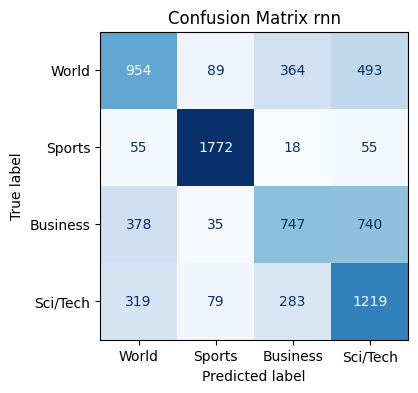

array([[ 954,   89,  364,  493],
       [  55, 1772,   18,   55],
       [ 378,   35,  747,  740],
       [ 319,   79,  283, 1219]])

In [30]:
plot_confusion_matrix(
    model=rnn_model,
    dataloader=test_loader,
    class_names=labels,
    device=device,
    rnn_type="rnn"
)

### Confusion Matrix GRU <a name="cm_gru" />

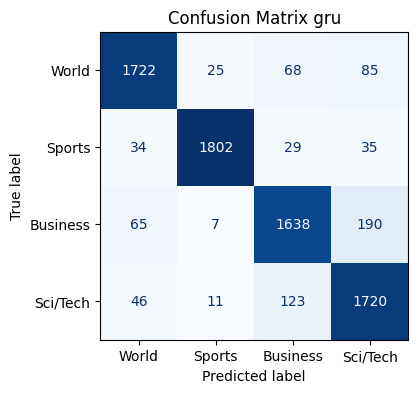

array([[1722,   25,   68,   85],
       [  34, 1802,   29,   35],
       [  65,    7, 1638,  190],
       [  46,   11,  123, 1720]])

In [31]:
plot_confusion_matrix(
    model=gru_model,
    dataloader=test_loader,
    class_names=labels,
    device=device,
    rnn_type="gru"
)

### Confusion Matrix LSTM <a name="cm_lstm" />

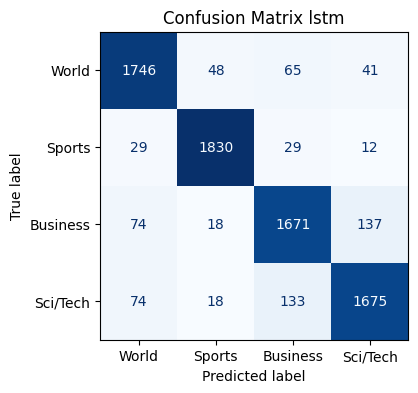

array([[1746,   48,   65,   41],
       [  29, 1830,   29,   12],
       [  74,   18, 1671,  137],
       [  74,   18,  133, 1675]])

In [32]:
plot_confusion_matrix(
    model=lstm_model,
    dataloader=test_loader,
    class_names=labels,
    device=device,
    rnn_type="lstm"
)

# Model Architecture and Training Setup <a name="arch" />

The implemented text classification model is composed of three main components: an embedding layer, a recurrent neural network, and a fully connected output layer. The embedding layer transforms each token index into a dense vector representation of dimension 300. These embeddings provide a continuous representation of words that can capture semantic relationships between tokens and serve as the input to the recurrent layer.

To model sequential dependencies in the text, three different recurrent architectures were evaluated: a simple Recurrent Neural Network (RNN), a Gated Recurrent Unit (GRU), and a Long Short-Term Memory network (LSTM). Each recurrent model consists of two stacked layers with 256 hidden units. The recurrent network processes the token embeddings sequentially and produces hidden states that summarize the contextual information of the input sequence. The final hidden state from the last recurrent layer is used as the representation of the entire text sequence.

The output of the recurrent network is passed to a fully connected linear layer that maps the hidden representation to four output logits corresponding to the AG_NEWS categories: World, Sports, Business, and Sci/Tech. The model is trained using the CrossEntropyLoss function, which combines a softmax activation with a negative log-likelihood objective suitable for multi-class classification.

During training, the Adam optimizer was used with a learning rate of
$1 \times 10^{-3}$. The input text sequences were tokenized using the basic_english tokenizer from TorchText and converted to numerical indices through a vocabulary mapping. Each sequence was padded or truncated to a fixed length of 50 tokens to ensure consistent batch dimensions. The dataset was divided into training and validation subsets (90% and 10% respectively), and model performance was evaluated using classification accuracy on the validation and test sets. Additionally, confusion matrices were generated to analyze the classification performance across different categories.



# Results and Discusion <a name="results" />

To evaluate the effectiveness of different recurrent architectures for text classification, three models were trained using the same configuration: a simple RNN, a GRU, and an LSTM network. All models used the same embedding dimension (300), two recurrent layers with 256 hidden units, and were trained using the Adam optimizer with a learning rate of $1 \times 10^{-3}$.  Performance was evaluated using classification accuracy on the test dataset, and confusion matrices were analyzed to understand the distribution of prediction errors.

The baseline **RNN** model achieved a test accuracy of **0.6174**, which was significantly lower than the other architectures. The confusion matrix shows that the model struggled particularly with the *World* and *Business* categories, frequently misclassifying them as *Sci/Tech*. For instance, many samples belonging to the *Business* class were predicted as *Sci/Tech*, indicating that the model had difficulty capturing the contextual relationships necessary to distinguish between these categories. This behavior is consistent with known limitations of standard RNNs, which often struggle with learning long-range dependencies due to vanishing gradient issues.

In contrast, the **GRU** model achieved a much higher test accuracy of **0.9055**, representing a substantial improvement over the simple RNN. The confusion matrix shows a strong diagonal pattern, indicating that the majority of samples were correctly classified. Only a relatively small number of misclassifications occurred, mostly between the *Business* and *Sci/Tech* categories. This improvement can be attributed to the gating mechanisms present in GRUs, which allow the network to better control the flow of information through the sequence and preserve relevant contextual information.

The **LSTM** model achieved the highest test accuracy of **0.9108**, slightly outperforming the GRU model. Similar to the GRU results, the confusion matrix shows strong diagonal dominance, with most predictions correctly classified. The LSTM architecture demonstrated slightly better performance in distinguishing between the *Business* and *Sci/Tech* categories, which are often semantically similar in news datasets. The additional memory cell and gating mechanisms in LSTM networks enable the model to better retain long-term contextual information, which can lead to improved classification performance.

Overall, the results demonstrate a clear performance gap between the basic RNN architecture and the gated recurrent models (GRU and LSTM). While the RNN struggled to capture sufficient contextual information for accurate classification, both GRU and LSTM significantly improved performance by addressing the limitations associated with traditional recurrent networks. The difference between GRU and LSTM performance was relatively small, suggesting that both architectures are effective for this task, with LSTM providing a marginal advantage.

# Conclusions <a name="conclusions" />

In this activity, recurrent neural network architectures were applied to the task of news article classification using the AG_NEWS dataset. Three different models (RNN, GRU, and LSTM) were implemented and evaluated using the same experimental configuration in order to compare their effectiveness in modeling sequential textual data. The results showed a clear performance difference between the basic RNN architecture and the gated recurrent models.

The standard RNN achieved the lowest accuracy, highlighting the limitations of simple recurrent networks when handling longer contextual dependencies in natural language. In contrast, both GRU and LSTM architectures significantly improved classification performance by incorporating gating mechanisms that help preserve relevant information across time steps. Among the evaluated models, the LSTM achieved the highest test accuracy, although the difference between GRU and LSTM was relatively small.

Overall, the experiments demonstrate that gated recurrent architectures are considerably more effective for text classification tasks compared to traditional RNNs. These findings are consistent with the theoretical advantages of GRU and LSTM networks in capturing long-term dependencies in sequential data. Future improvements could include experimenting with pretrained embeddings, bidirectional recurrent networks, or transformer-based architectures to further enhance classification performance.